# Stock 5-Day Return Prediction — EDA + Multi-Model ML with Robust Losses (10 Tickers)

**Dataset:** [US Stock Dataset](https://www.kaggle.com/datasets/footballjoe789/us-stock-dataset) → `Stock History`  
**Task:** Regression — predict the **next 5-day return** from the last 20 days of price/volume history plus 4 technical indicators (RSI, ADX, Bollinger bandwidth, MACD histogram) already present in the raw CSVs.  
Example: price = 100, model predicts `+0.03` → about **+3% over 5 trading days** → implied price ≈ 103.  
This is a regression problem, not classification.

### Why this setup
An earlier next-day version of this project (1-day horizon) showed that a naive "predict 0% change" baseline is genuinely hard to beat — daily returns are mostly noise. Moving the target to a 5-day horizon gave a small but real improvement in directional accuracy. While pushing that further, most models (especially the ones trained with plain MSE) kept collapsing toward predicting ~0% almost every time. That trick lowers RMSE without producing a useful forecast, so this version switches to more robust losses (Huber / MAE / SmoothL1) and adds quantile predictions so the notebook reports a range instead of pretending to know one exact number.

### What this notebook includes
1. **EDA** on 10 large-cap stocks (prices, returns, volume, correlations)
2. **Regression models trained with robust losses** + an LSTM comparison:
   - Naive (predict **0%** return)
   - Ridge (MSE, kept as a reference to show the collapse problem)
   - Huber, HistGradientBoosting (MAE), XGBoost (MAE), Random Forest
   - LSTM trained with SmoothL1 instead of MSE
3. Leakage-safe scaling (fit on **train only**)
4. Chronological train / val / test split with honest metrics vs a naive baseline
5. **Quantile (Q10 / Q50 / Q90) predictions** — uncertainty bands instead of a single point guess
6. **Leakage / alignment audit** + a short walk-forward check

## 1) Imports & config

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, HuberRegressor, QuantileRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

CONFIG = {
    "tickers": ["AAPL", "MSFT", "GOOG", "AMZN", "META", "NVDA", "JPM", "JNJ", "XOM", "PG"],
    "fallback_tickers": ["IBM", "INTC", "CSCO", "PEP", "KO", "WMT", "DIS", "NFLX", "AMD", "BA"],
    "price_col_candidates": ["Adj Close", "AdjClose", "adjclose", "Adjusted Close", "Close"],
    "volume_col_candidates": ["Volume", "volume"],
    "date_col_candidates": ["Date", "date", "Datetime", "datetime"],
    "window_size": 20,
    "horizon": 5,
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "min_rows": 800,
    "model": {"hidden_size": 16, "num_layers": 1, "dropout": 0.1},
    "training": {
        "batch_size": 64,
        "epochs": 30,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "seed": 42,
    },
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print(f"Target: next-{CONFIG['horizon']}-day return | window={CONFIG['window_size']} | robust losses + quantiles")


Device: cuda
Target: next-5-day return | window=20 | robust losses + quantiles


## 2) Locate `Stock History` + load helpers

In [2]:
def find_stock_history_dir(roots=None):
    if roots is None:
        roots = [Path("/kaggle/input"), Path("/kaggle/input/us-stock-dataset"), Path("."), Path("./data")]

    candidates = []
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob("*"):
            if not p.is_dir():
                continue
            name = p.name.lower().replace("_", " ")
            
            # --- التعديل هنا ---
            # تم حذف كلمة "stocks" لإجباره على اختيار فولدر StockHistory فقط
            if name in {"stock history", "stockhistory", "full history", "full_history"}:
                candidates.append(p)
            elif "stock" in p.name.lower() and "hist" in p.name.lower():
                candidates.append(p)

    if not candidates:
        for root in roots:
            if not root.exists():
                continue
            for p in root.rglob("*.csv"):
                parent = p.parent
                if len(list(parent.glob("*.csv"))) >= 50:
                    candidates.append(parent)
                    break

    if not candidates:
        raise FileNotFoundError(
            "Could not find Stock History. Add Kaggle dataset footballjoe789/us-stock-dataset."
        )

    candidates = sorted(set(candidates), key=lambda p: len(list(p.glob("*.csv"))), reverse=True)
    best = candidates[0]
    print(f"Using: {best} ({len(list(best.glob('*.csv')))} csv files)")
    return best


def _pick_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in df.columns:
            return name
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None


def resolve_ticker_path(data_dir: Path, ticker: str):
    for pat in [f"{ticker}.csv", f"{ticker.lower()}.csv", f"{ticker.upper()}.csv", f"{ticker}_*.csv"]:
        hits = list(data_dir.glob(pat))
        if hits:
            return hits[0]
    return None


SELECTED_INDICATORS = ["RSI_14", "ADX_14", "BBB_5_2.0", "MACDh_12_26_9"]

# single source of truth for the feature set -- used by the main pipeline,
# the walk-forward check, and the live-holdout script, so all three always
# train/evaluate the exact same model instead of silently drifting apart
FEATURE_COLUMNS = ["return_1d", "return_5d", "log_volume"] + SELECTED_INDICATORS

def load_ticker(data_dir: Path, ticker: str) -> pd.DataFrame:
    path = resolve_ticker_path(data_dir, ticker)
    if path is None:
        raise FileNotFoundError(f"Missing CSV for {ticker}")

    df = pd.read_csv(path)
    date_col = _pick_col(df, CONFIG["date_col_candidates"])
    price_col = _pick_col(df, CONFIG["price_col_candidates"])
    vol_col = _pick_col(df, CONFIG["volume_col_candidates"])
    
    out = pd.DataFrame({
        "date": pd.to_datetime(df[date_col], errors="coerce"),
        "adj_close": pd.to_numeric(df[price_col], errors="coerce"),
        "volume": pd.to_numeric(df[vol_col], errors="coerce") if vol_col else np.nan,
    })
    
    out = out.dropna(subset=["date", "adj_close"]).sort_values("date").drop_duplicates("date")
    
    out["log_volume"] = np.log1p(out["volume"].fillna(out["volume"].median()))
    out["return_1d"] = out["adj_close"].pct_change()
    out["return_5d"] = out["adj_close"].pct_change(periods=5)
    
    for col in SELECTED_INDICATORS:
        out[col] = pd.to_numeric(df[col], errors="coerce")
        
    out = out.dropna().reset_index(drop=True)

    if len(out) < CONFIG["min_rows"]:
        raise ValueError(f"{ticker}: only {len(out)} rows")

    out.attrs["price_col_used"] = price_col
    out.attrs["ticker"] = ticker
    return out


def pick_available_tickers(data_dir: Path, preferred, fallback, n=10):
    chosen, errors = [], []
    for t in list(preferred) + list(fallback):
        if t in chosen:
            continue
        try:
            load_ticker(data_dir, t)
            chosen.append(t)
        except Exception as e:
            errors.append((t, str(e)))
        if len(chosen) >= n:
            break

    if len(chosen) < n:
        for p in sorted(data_dir.glob("*.csv")):
            t = p.stem.upper()
            if t in chosen:
                continue
            try:
                load_ticker(data_dir, t)
                chosen.append(t)
            except Exception as e:
                errors.append((t, str(e)))
            if len(chosen) >= n:
                break

    print("Selected:", chosen)
    if errors:
        print("Skipped (sample):", errors[:5])
    if len(chosen) < n:
        raise RuntimeError(f"Only found {len(chosen)} usable tickers")
    return chosen


DATA_DIR = find_stock_history_dir()
TICKERS = pick_available_tickers(DATA_DIR, CONFIG["tickers"], CONFIG["fallback_tickers"], n=10)

stock_data = {t: load_ticker(DATA_DIR, t) for t in TICKERS}
print("Loaded", len(stock_data), "tickers")

Using: /kaggle/input/datasets/footballjoe789/us-stock-dataset/Data/StockHistory (6227 csv files)
Selected: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA', 'JPM', 'JNJ', 'XOM', 'PG']
Loaded 10 tickers


## 3) EDA — Exploratory Data Analysis

Before building any model it's worth just looking at the data: how much history each ticker has, how volatile they are, and whether they move together. This is the same EDA pass used for the earlier 1-day and 5-day versions — nothing about it depends on the prediction horizon, so it carries over unchanged.

In [3]:
# 3.1 Coverage / summary table 
eda_rows = []
for t, df in stock_data.items():
    r = df["return_1d"].dropna()
    eda_rows.append({
        "ticker": t,
        "rows": len(df),
        "start": df["date"].min().date(),
        "end": df["date"].max().date(),
        "last_price": df["adj_close"].iloc[-1],
        "min_price": df["adj_close"].min(),
        "max_price": df["adj_close"].max(),
        "mean_return": r.mean(),
        "std_return": r.std(),
        "ann_vol": r.std() * np.sqrt(252),
        "avg_volume": df["volume"].mean(),
        "price_col": df.attrs.get("price_col_used"),
    })

eda_summary = pd.DataFrame(eda_rows).sort_values("ticker")
print("=== EDA summary ===")
display(eda_summary.round(4))


=== EDA summary ===


,ticker,rows,start,end,last_price,min_price,max_price,mean_return,std_return,ann_vol,avg_volume,price_col
0,AAPL,11195,1981-01-30,2025-07-01,207.82,0.0377,258.3967,0.0011,0.0277,0.4401,3.134173e+08,Close
3,AMZN,7043,1997-07-02,2025-07-01,220.46,0.0794,242.0600,0.0017,0.0350,0.5559,1.349708e+08,Close
2,GOOG,5217,2004-10-06,2025-07-01,176.91,3.3490,207.2245,0.0009,0.0193,0.3063,1.108338e+08,Close
7,JNJ,15948,1962-02-16,2025-07-01,155.92,0.0395,168.7965,0.0006,0.0144,0.2281,5.713856e+06,Close
6,JPM,11383,1980-05-02,2025-07-01,290.41,1.1614,290.4100,0.0007,0.0222,0.3521,1.194448e+07,Close
4,META,3265,2012-07-06,2025-07-01,719.22,17.6333,738.0900,0.0013,0.0250,0.3962,2.854428e+07,Close
1,MSFT,9869,1986-04-30,2025-07-01,492.05,0.0575,497.4500,0.0011,0.0210,0.3330,5.591391e+07,Close
5,NVDA,6618,1999-03-11,2025-07-01,153.30,0.0313,157.9900,0.0019,0.0378,0.5995,5.960940e+08,Close
9,PG,15948,1962-02-16,2025-07-01,161.22,0.1619,177.5044,0.0005,0.0134,0.2131,5.131969e+06,Close
8,XOM,15948,1962-02-16,2025-07-01,109.24,0.0847,122.1211,0.0005,0.0145,0.2299,9.579674e+06,Close


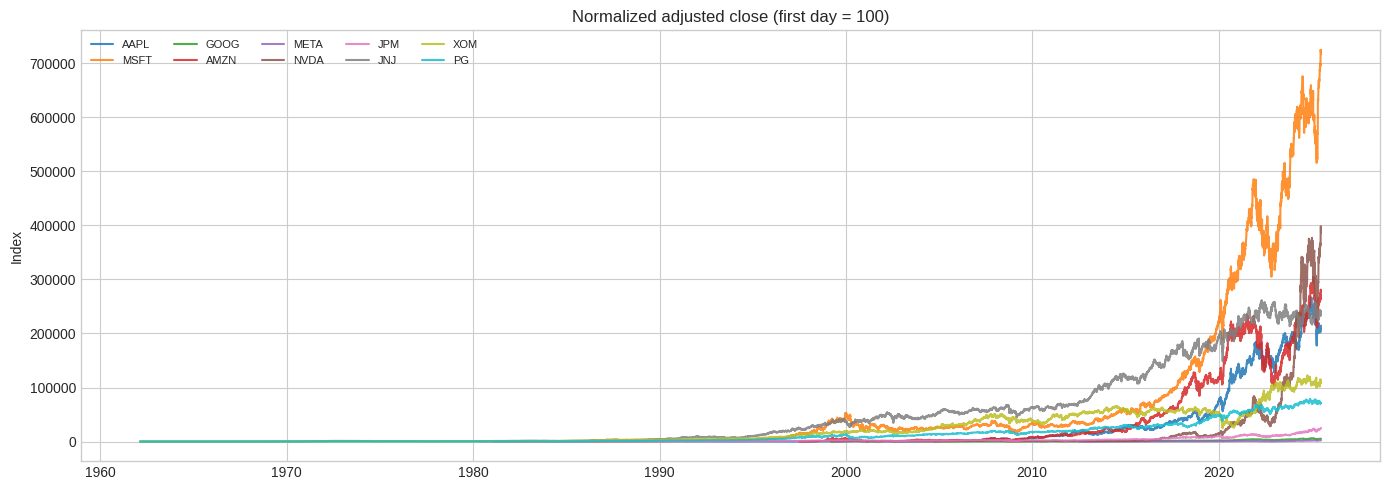

In [4]:
# --- 3.2 Normalized price paths (start=100) for visual comparison ---
fig, ax = plt.subplots(figsize=(14, 5))
for t, df in stock_data.items():
    s = df.set_index("date")["adj_close"].dropna()
    s = 100.0 * s / s.iloc[0]
    ax.plot(s.index, s.values, label=t, alpha=0.85)
ax.set_title("Normalized adjusted close (first day = 100)")
ax.set_ylabel("Index")
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.show()


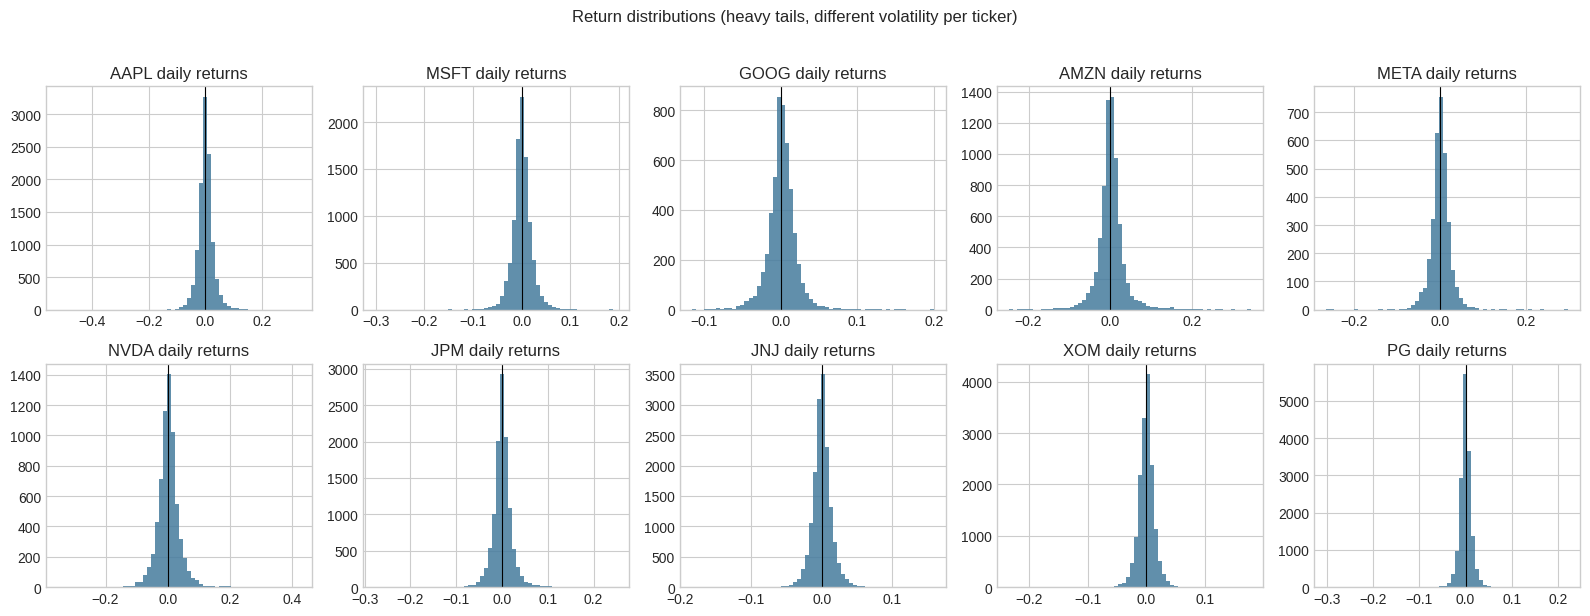

In [5]:
# 3.3 Daily return distributions
fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharex=False)
axes = axes.ravel()
for i, t in enumerate(TICKERS):
    r = stock_data[t]["return_1d"].dropna()
    axes[i].hist(r, bins=60, color="#457b9d", alpha=0.85)
    axes[i].set_title(f"{t} daily returns")
    axes[i].axvline(0, color="black", linewidth=0.8)
plt.suptitle("Return distributions (heavy tails, different volatility per ticker)", y=1.02)
plt.tight_layout()
plt.show()


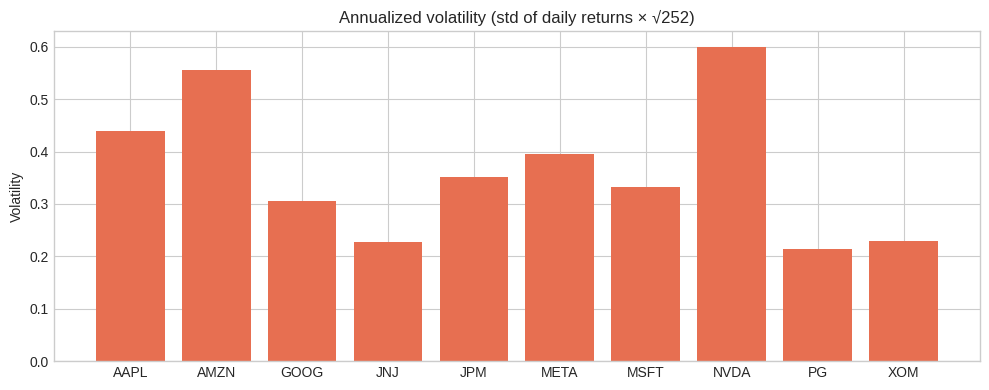

In [6]:
# 3.4 Annualized volatility bar chart 
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(eda_summary["ticker"], eda_summary["ann_vol"], color="#e76f51")
ax.set_title("Annualized volatility (std of daily returns × √252)")
ax.set_ylabel("Volatility")
plt.tight_layout()
plt.show()


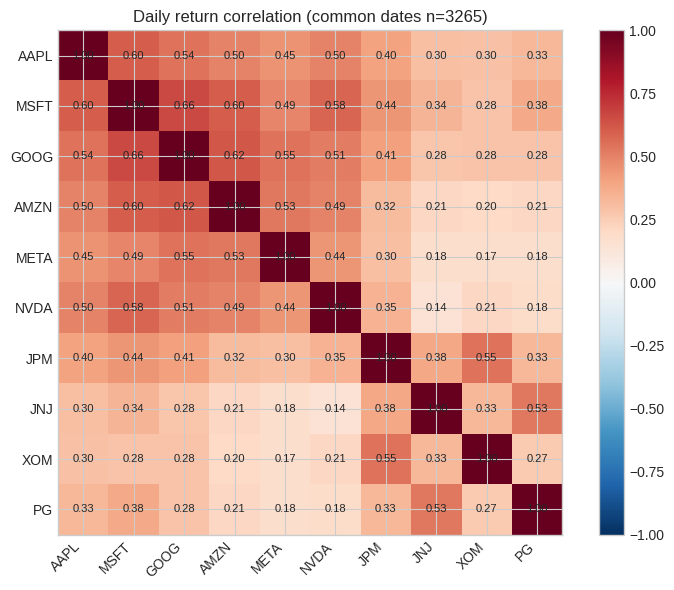

,AAPL,MSFT,GOOG,AMZN,META,NVDA,JPM,JNJ,XOM,PG
AAPL,1.000,0.602,0.544,0.497,0.446,0.496,0.400,0.298,0.296,0.331
MSFT,0.602,1.000,0.659,0.602,0.490,0.580,0.439,0.341,0.283,0.375
GOOG,0.544,0.659,1.000,0.621,0.546,0.512,0.408,0.280,0.284,0.283
AMZN,0.497,0.602,0.621,1.000,0.527,0.493,0.317,0.209,0.199,0.205
META,0.446,0.490,0.546,0.527,1.000,0.438,0.299,0.177,0.174,0.180
NVDA,0.496,0.580,0.512,0.493,0.438,1.000,0.345,0.144,0.211,0.180
JPM,0.400,0.439,0.408,0.317,0.299,0.345,1.000,0.385,0.546,0.330
JNJ,0.298,0.341,0.280,0.209,0.177,0.144,0.385,1.000,0.331,0.531
XOM,0.296,0.283,0.284,0.199,0.174,0.211,0.546,0.331,1.000,0.265
PG,0.331,0.375,0.283,0.205,0.180,0.180,0.330,0.531,0.265,1.000


In [7]:
# 3.5 Return correlation heatmap (aligned on common dates) 
ret_panel = {}
for t, df in stock_data.items():
    ret_panel[t] = df.set_index("date")["return_1d"]
ret_df = pd.DataFrame(ret_panel).dropna(how="any")
corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(f"Daily return correlation (common dates n={len(ret_df)})")
plt.tight_layout()
plt.show()

display(corr.round(3))


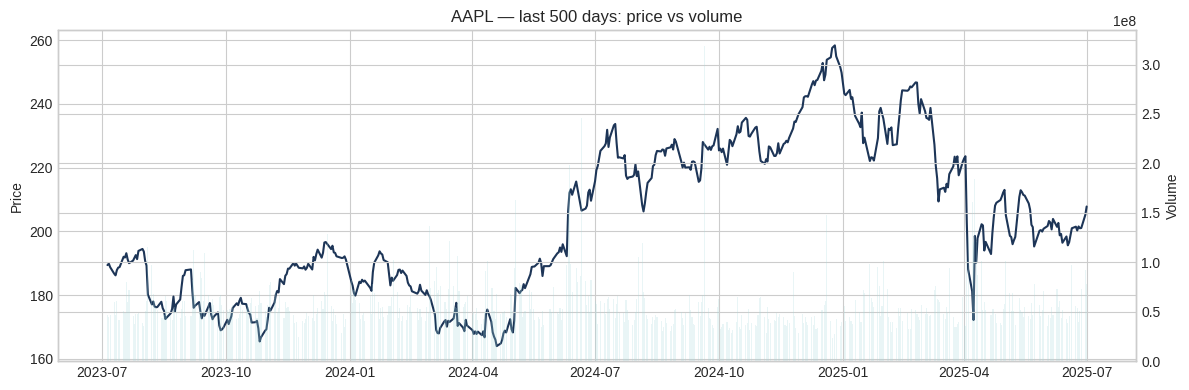

EDA takeaways for modeling:
- Prices are non-stationary (levels drift over years) -> absolute-price ML usually loses to naive.
- Returns are noisy and heavy-tailed; volatility differs a lot by ticker.
- Several tickers move together (correlation) -> there's a shared market factor.
- Each ticker is still modeled separately here, for a clean apples-to-apples comparison.


In [8]:
# 3.6 Price vs volume example (first ticker) 
ex = TICKERS[0]
df_ex = stock_data[ex].tail(500)
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(df_ex["date"], df_ex["adj_close"], color="#1d3557", label="Adj Close")
ax1.set_ylabel("Price")
ax2 = ax1.twinx()
ax2.bar(df_ex["date"], df_ex["volume"], alpha=0.25, color="#a8dadc", label="Volume")
ax2.set_ylabel("Volume")
ax1.set_title(f"{ex} — last 500 days: price vs volume")
plt.tight_layout()
plt.show()

print(
    "EDA takeaways for modeling:\n"
    "- Prices are non-stationary (levels drift over years) -> absolute-price ML usually loses to naive.\n"
    "- Returns are noisy and heavy-tailed; volatility differs a lot by ticker.\n"
    "- Several tickers move together (correlation) -> there's a shared market factor.\n"
    "- Each ticker is still modeled separately here, for a clean apples-to-apples comparison."
)


## 4) Leakage-safe dataset building (5-day return target)

- Split the timeline **first**, before touching any statistics
- Fit the feature scaler and the target scaler on the **train slice only**
- Features: 20-day window of `[return_1d, log_volume]` (same features as the 1-day and 5-day baseline versions)
- Target: **5-day forward return**, `r = (P_{t+5} - P_t) / P_t`
- Classical models use flattened windows; the LSTM uses the raw `(window, features)` sequence
- Naive baseline = **0% return** over the 5-day horizon (no expected move)

In [9]:
class TrainOnlyScaler:
    """Winsorizes each feature column to TRAIN-only percentiles, then
    standardizes using TRAIN-only mean/std of the *clipped* series.

    Why: features like BBB_5_2.0 (Bollinger bandwidth = (upper-lower)/middle)
    explode when the historical price is near zero (e.g. NVDA/AAPL split-
    adjusted prices in the 1980s-90s), and MACDh_12_26_9 is in raw price
    units so it isn't scale-invariant across decades of price growth. Those
    outliers dominate the mean/std of a plain StandardScaler and wreck the
    linear models (Ridge/Huber/QuantileRegressor). Clipping to train-only
    percentiles before fitting mean/std removes that leverage without
    discarding the feature or leaking test-period statistics.
    """
    def __init__(self, clip_percentiles=(1, 99)):
        self.mean_ = None
        self.std_ = None
        self.low_ = None
        self.high_ = None
        self.clip_percentiles = clip_percentiles

    def fit(self, x):
        lo, hi = self.clip_percentiles
        self.low_ = np.percentile(x, lo, axis=0, keepdims=True)
        self.high_ = np.percentile(x, hi, axis=0, keepdims=True)
        x_clipped = np.clip(x, self.low_, self.high_)
        self.mean_ = x_clipped.mean(axis=0, keepdims=True)
        self.std_ = x_clipped.std(axis=0, keepdims=True)
        self.std_ = np.where(self.std_ < 1e-8, 1.0, self.std_)
        return self

    def transform(self, x):
        x_clipped = np.clip(x, self.low_, self.high_)
        return (x_clipped - self.mean_) / self.std_

    def inverse(self, x_scaled, col=0):
        return x_scaled * self.std_[0, col] + self.mean_[0, col]


def chronological_split_indices(n, train_ratio, val_ratio):
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    return slice(0, n_train), slice(n_train, n_train + n_val), slice(n_train + n_val, n)


def prepare_ticker_datasets(df, config=CONFIG):
    """Build leakage-safe windows that predict the H-day forward return."""
    window = int(config["window_size"])
    horizon = int(config["horizon"])
    work = df.dropna(subset=["return_1d"]).sort_values("date").reset_index(drop=True)
    work.attrs["ticker"] = df.attrs.get("ticker", "UNK")

    price = work["adj_close"].to_numpy(np.float64)
    dates = work["date"].to_numpy()
    feats_raw = work[FEATURE_COLUMNS].to_numpy(np.float64)  # 7 features: returns + volume + technical indicators

    # forward H-day return for every day that has H days left after it
    fwd = np.full(len(work), np.nan, dtype=np.float64)
    fwd[: len(work) - horizon] = (price[horizon:] - price[:-horizon]) / np.maximum(price[:-horizon], 1e-12)

    train_idx, val_idx, test_idx = chronological_split_indices(
        len(work), config["train_ratio"], config["val_ratio"]
    )

    # Feature scaler: TRAIN rows only
    feat_scaler = TrainOnlyScaler().fit(feats_raw[train_idx])
    feats = feat_scaler.transform(feats_raw)

    # Target: clip outliers using TRAIN-only percentiles, then scale using
    # TRAIN-only mean/std of the *clipped* series -- same approach as the
    # live-holdout script (cell 30), so the model actually being validated
    # here is the same one that gets deployed there. Clipping only changes
    # what the model trains on; y_return below stays the raw, unclipped
    # forward return, so evaluation is never softened by this.
    train_label_idx = np.arange(train_idx.start, train_idx.stop)
    train_label_idx = train_label_idx[train_label_idx < (len(work) - horizon)]
    train_fwd = fwd[train_label_idx]
    train_fwd = train_fwd[np.isfinite(train_fwd)]
    if len(train_fwd) > 0:
        p1, p99 = np.percentile(train_fwd, [1, 99])
        fwd_clipped = np.clip(fwd, p1, p99)
    else:
        fwd_clipped = fwd

    y_mean = float(np.nanmean(fwd_clipped[train_label_idx]))
    y_std = float(np.nanstd(fwd_clipped[train_label_idx]))
    if not np.isfinite(y_std) or y_std < 1e-8:
        y_std = 1.0
    y_scaled = (fwd_clipped - y_mean) / y_std

    # Build windows: feature window ends at day t, target is the return from t to t+horizon
    xs, ys, t_list = [], [], []
    max_i = len(work) - window - horizon
    for i in range(max_i + 1):
        t = i + window - 1
        xs.append(feats[i:i + window])
        ys.append(y_scaled[t])
        t_list.append(t)

    X_all = np.asarray(xs, np.float32)
    y_all = np.asarray(ys, np.float32)
    t_idx = np.asarray(t_list, np.int64)

    y_return = fwd[t_idx]
    price_t = price[t_idx]
    price_future = price[t_idx + horizon]
    y_dates = dates[t_idx]
    feat_end_dates = dates[t_idx]
    target_end_dates = dates[t_idx + horizon]

    m_train = t_idx < train_idx.stop
    m_val = (t_idx >= train_idx.stop) & (t_idx < val_idx.stop)
    m_test = t_idx >= val_idx.stop

    bundles = {}
    for name, mask in [("train", m_train), ("val", m_val), ("test", m_test)]:
        X = X_all[mask]
        n = len(X)
        bundles[name] = {
            "X_seq": X,
            "X_flat": X.reshape(n, -1) if n else np.zeros((0, window * feats.shape[1]), np.float32),
            "y": y_all[mask],                     # scaled H-day return target
            "y_return": y_return[mask],           # raw H-day return target
            "price_t": price_t[mask],             # price known at forecast time
            "price_future": price_future[mask],   # price H days later (for recon checks)
            "dates": y_dates[mask],
            "feat_end_dates": feat_end_dates[mask],
            "target_end_dates": target_end_dates[mask],
            "abs_idx": t_idx[mask],
            "naive_return": np.zeros(n, dtype=np.float64),  # predict 0%
        }

    meta = {
        "feat_scaler": feat_scaler,
        "y_mean": y_mean,
        "y_std": y_std,
        "n_features": feats.shape[1],
        "ticker": work.attrs.get("ticker", df.attrs.get("ticker", "UNK")),
        "n_rows": len(work),
        "train_end": int(train_idx.stop),
        "val_end": int(val_idx.stop),
        "window": window,
        "horizon": horizon,
    }
    return bundles, meta


def inverse_return(y_scaled, meta):
    return np.asarray(y_scaled, dtype=np.float64) * meta["y_std"] + meta["y_mean"]


def return_to_price(price_t, ret):
    return np.asarray(price_t, dtype=np.float64) * (1.0 + np.asarray(ret, dtype=np.float64))


# quick smoke test on one ticker before running the full loop
_b, _m = prepare_ticker_datasets(stock_data[TICKERS[0]])
print(
    f"Smoke test {TICKERS[0]}: horizon={_m['horizon']} window={_m['window']} "
    f"train={len(_b['train']['y'])} val={len(_b['val']['y'])} test={len(_b['test']['y'])}"
)


Smoke test AAPL: horizon=5 window=20 train=7817 val=1679 test=1675


## 5) Models + metrics (robust losses)

The 5-day baseline used plain MSE for the linear model and the LSTM, and several models ended up predicting something close to 0% almost every day — a low RMSE, but not a real forecast. Here the loss functions are swapped for options that don't get pulled toward the mean quite as hard: Huber for the linear model, absolute error (MAE) for the tree models, and SmoothL1 for the LSTM. Ridge with MSE is still included as a reference point, specifically so the collapse is visible in the comparison.

| Model | Role |
|---|---|
| Naive | always predicts 0% |
| Ridge (MSE) | reference — this is where the collapse shows up |
| Huber | robust linear regression |
| HGB (MAE) | gradient-boosted trees, absolute-error loss |
| Random Forest | tree ensemble, no special loss handling |
| XGBoost (MAE) | boosted trees, absolute-error objective |
| LSTM (SmoothL1) | sequence model, Huber-like loss instead of MSE |

An extra metric is added on top of RMSE / MAE / directional accuracy: `pred_std_ratio = std(predictions) / std(actual)`. A ratio close to 0 means the model is barely moving away from 0% (the collapse). A ratio closer to 1 means the model's predictions actually spread out the way the real returns do.

In [10]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def directional_accuracy_returns(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    true_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    mask = true_dir != 0
    if mask.sum() == 0:
        return np.nan
    return float((true_dir[mask] == pred_dir[mask]).mean())


def eval_returns(y_true, y_pred, model_name):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    act_std = float(np.std(y_true))
    pred_std = float(np.std(y_pred))
    return {
        "model": model_name,
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "dir_acc": directional_accuracy_returns(y_true, y_pred),
        "pred_std": pred_std,
        "pred_std_ratio": pred_std / max(act_std, 1e-12),
    }


class SeqDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_lstm_smoothl1(bundles, meta, config=CONFIG, verbose=False):
    """Same LSTM as before, but trained with SmoothL1 (Huber-like) instead of MSE."""
    set_seed(config["training"]["seed"])
    train_loader = DataLoader(
        SeqDataset(bundles["train"]["X_seq"], bundles["train"]["y"]),
        batch_size=config["training"]["batch_size"], shuffle=True,
    )
    val_loader = DataLoader(
        SeqDataset(bundles["val"]["X_seq"], bundles["val"]["y"]),
        batch_size=config["training"]["batch_size"], shuffle=False,
    )
    test_loader = DataLoader(
        SeqDataset(bundles["test"]["X_seq"], bundles["test"]["y"]),
        batch_size=config["training"]["batch_size"], shuffle=False,
    )

    model = LSTMRegressor(
        n_features=meta["n_features"],
        hidden_size=config["model"]["hidden_size"],
        num_layers=config["model"]["num_layers"],
        dropout=config["model"]["dropout"],
    ).to(DEVICE)

    criterion = nn.SmoothL1Loss(beta=1.0)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config["training"]["lr"], weight_decay=config["training"]["weight_decay"]
    )

    best_state, best_val, bad, patience = None, float("inf"), 0, 6
    for epoch in range(1, config["training"]["epochs"] + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        vals = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                vals.append(criterion(model(xb), yb).item())
        va = float(np.mean(vals)) if vals else np.inf
        if va < best_val - 1e-6:
            best_val = va
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if verbose and epoch % 10 == 0:
            print(f"  LSTM-SmoothL1 epoch {epoch}: val={va:.5f}")
        if bad >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            preds.append(model(xb.to(DEVICE)).cpu().numpy())
    pred_scaled = np.concatenate(preds) if preds else np.array([])
    return inverse_return(pred_scaled, meta), model


def get_models(seed=42):
    return {
        "Ridge": Ridge(alpha=100.0),
        "Huber": HuberRegressor(epsilon=1.35, alpha=0.001),
        "RandomForest": RandomForestRegressor(
            n_estimators=100, 
            max_depth=4, 
            min_samples_leaf=20, 
            random_state=seed
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            max_depth=3, 
            learning_rate=0.05, 
            min_samples_leaf=30, 
            random_state=seed
        ),
        "XGBoost": XGBRegressor(
            n_estimators=100, 
            max_depth=3, 
            learning_rate=0.05, 
            subsample=0.8, 
            colsample_bytree=0.8, 
            random_state=seed
        )
    }


def run_all_models_for_ticker(df, verbose=True):
    bundles, meta = prepare_ticker_datasets(df)
    ticker = meta["ticker"]
    y_true = bundles["test"]["y_return"]

    rows, preds_store = [], {}

    naive = bundles["test"]["naive_return"].copy()
    rows.append(eval_returns(y_true, naive, "Naive"))
    preds_store["Naive"] = naive

    Xtr, ytr = bundles["train"]["X_flat"], bundles["train"]["y"]
    Xte = bundles["test"]["X_flat"]

    for name, model in get_models(CONFIG["training"]["seed"]).items():
        model.fit(Xtr, ytr)
        pred = inverse_return(model.predict(Xte), meta)
        rows.append(eval_returns(y_true, pred, name))
        preds_store[name] = pred
        if verbose:
            r = rows[-1]
            print(
                f"{ticker} | {name:14s} RMSE={r['rmse']:.5f}  "
                f"DirAcc={r['dir_acc']:.3f}  std_ratio={r['pred_std_ratio']:.3f}"
            )

    lstm_pred, lstm_model = train_lstm_smoothl1(bundles, meta, verbose=False)
    rows.append(eval_returns(y_true, lstm_pred, "LSTM(SmoothL1)"))
    preds_store["LSTM(SmoothL1)"] = lstm_pred
    if verbose:
        r = rows[-1]
        print(
            f"{ticker} | {'LSTM(SmoothL1)':14s} RMSE={r['rmse']:.5f}  "
            f"DirAcc={r['dir_acc']:.3f}  std_ratio={r['pred_std_ratio']:.3f}"
        )

    out = pd.DataFrame(rows)
    out.insert(0, "ticker", ticker)
    naive_rmse = float(out.loc[out["model"] == "Naive", "rmse"].iloc[0])
    out["rmse_vs_naive_pct"] = 100.0 * (naive_rmse - out["rmse"]) / max(naive_rmse, 1e-12)

    return {
        "metrics": out,
        "preds": preds_store,
        "y_true": y_true,
        "price_t": bundles["test"]["price_t"],
        "dates": bundles["test"]["dates"],
        "lstm_model": lstm_model,
        "meta": meta,
        "bundles": bundles,
    }


## 6) Train & evaluate all models on 10 tickers

In [11]:
all_metrics = []
details = {}

for i, ticker in enumerate(TICKERS, 1):
    print("\n" + "=" * 72)
    print(f"[{i}/{len(TICKERS)}] {ticker}")
    print("=" * 72)
    result = run_all_models_for_ticker(stock_data[ticker], verbose=True)
    details[ticker] = result
    all_metrics.append(result["metrics"])

metrics_df = pd.concat(all_metrics, ignore_index=True)
print("\n=== Full per-ticker / per-model test metrics ===")
display(metrics_df.round(4))



[1/10] AAPL
AAPL | Ridge          RMSE=0.04423  DirAcc=0.531  std_ratio=0.373
AAPL | Huber          RMSE=0.04717  DirAcc=0.520  std_ratio=0.547
AAPL | RandomForest   RMSE=0.04183  DirAcc=0.575  std_ratio=0.133
AAPL | HistGradientBoosting RMSE=0.04244  DirAcc=0.541  std_ratio=0.224
AAPL | XGBoost        RMSE=0.04227  DirAcc=0.561  std_ratio=0.180
AAPL | LSTM(SmoothL1) RMSE=0.04191  DirAcc=0.554  std_ratio=0.090

[2/10] MSFT
MSFT | Ridge          RMSE=0.03987  DirAcc=0.553  std_ratio=0.450
MSFT | Huber          RMSE=0.04269  DirAcc=0.537  std_ratio=0.631
MSFT | RandomForest   RMSE=0.04459  DirAcc=0.513  std_ratio=0.605
MSFT | HistGradientBoosting RMSE=0.04228  DirAcc=0.535  std_ratio=0.628
MSFT | XGBoost        RMSE=0.04213  DirAcc=0.488  std_ratio=0.619
MSFT | LSTM(SmoothL1) RMSE=0.03614  DirAcc=0.589  std_ratio=0.063

[3/10] GOOG
GOOG | Ridge          RMSE=0.04484  DirAcc=0.526  std_ratio=0.338
GOOG | Huber          RMSE=0.04599  DirAcc=0.527  std_ratio=0.426
GOOG | RandomForest   RMS

,ticker,model,rmse,mae,dir_acc,pred_std,pred_std_ratio,rmse_vs_naive_pct
0,AAPL,Naive,0.0420,0.0320,0.0000,0.0000,0.0000,0.0000
1,AAPL,Ridge,0.0442,0.0336,0.5307,0.0155,0.3733,-5.4387
2,AAPL,Huber,0.0472,0.0361,0.5200,0.0228,0.5466,-12.4485
3,AAPL,RandomForest,0.0418,0.0315,0.5749,0.0055,0.1330,0.2891
4,AAPL,HistGradientBoosting,0.0424,0.0321,0.5415,0.0093,0.2244,-1.1575
...,...,...,...,...,...,...,...,...
65,PG,Huber,0.0243,0.0177,0.5307,0.0059,0.2514,-2.2971
66,PG,RandomForest,0.0236,0.0172,0.5555,0.0025,0.1059,0.5298
67,PG,HistGradientBoosting,0.0244,0.0179,0.5198,0.0059,0.2485,-2.6819
68,PG,XGBoost,0.0239,0.0175,0.5257,0.0043,0.1804,-0.4373


## 7) Results comparison (project charts)

=== Average TEST metrics across 10 tickers (5-day return space) ===


,model,rmse,mae,dir_acc,pred_std_ratio,rmse_vs_naive_pct
2,LSTM(SmoothL1),0.0424,0.0319,0.5421,0.0906,0.2259
3,Naive,0.0425,0.0321,0.0000,0.0000,0.0000
4,RandomForest,0.0437,0.0332,0.5339,0.1884,-3.2978
5,Ridge,0.0441,0.0335,0.5219,0.3105,-3.9216
6,XGBoost,0.0442,0.0338,0.5249,0.2748,-4.3666
0,HistGradientBoosting,0.0445,0.0340,0.5230,0.2998,-5.3354
1,Huber,0.0456,0.0346,0.5241,0.4027,-7.1616


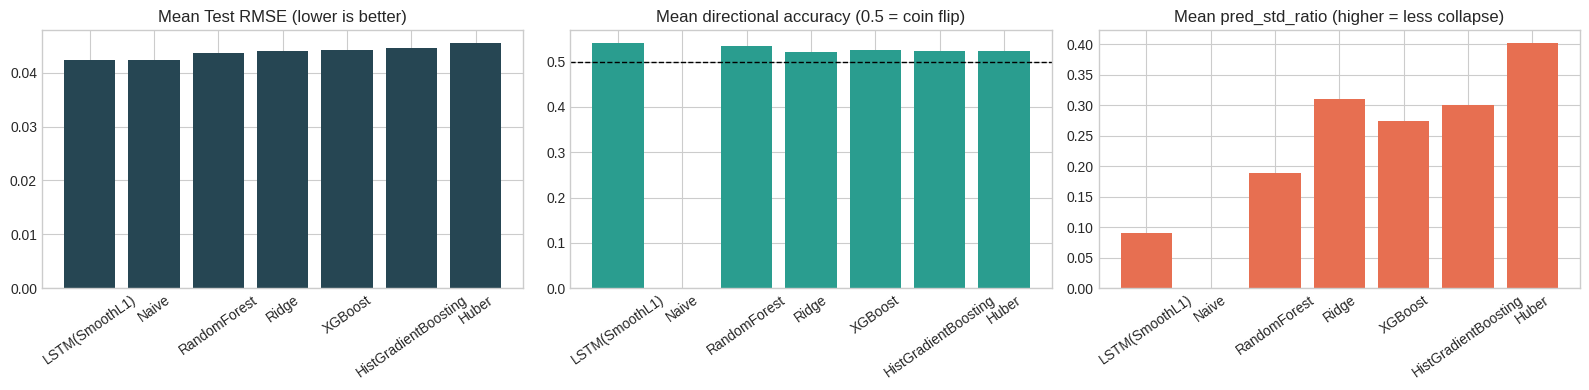

In [12]:
# Average metrics by model across the 10 tickers
avg = (
    metrics_df.groupby("model", as_index=False)[
        ["rmse", "mae", "dir_acc", "pred_std_ratio", "rmse_vs_naive_pct"]
    ]
    .mean()
    .sort_values("rmse")
)
print("=== Average TEST metrics across 10 tickers (5-day return space) ===")
display(avg.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(avg["model"], avg["rmse"], color="#264653")
axes[0].set_title("Mean Test RMSE (lower is better)")
axes[0].tick_params(axis="x", rotation=35)

axes[1].bar(avg["model"], avg["dir_acc"], color="#2a9d8f")
axes[1].axhline(0.5, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Mean directional accuracy (0.5 = coin flip)")
axes[1].tick_params(axis="x", rotation=35)

axes[2].bar(avg["model"], avg["pred_std_ratio"], color="#e76f51")
axes[2].set_title("Mean pred_std_ratio (higher = less collapse)")
axes[2].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


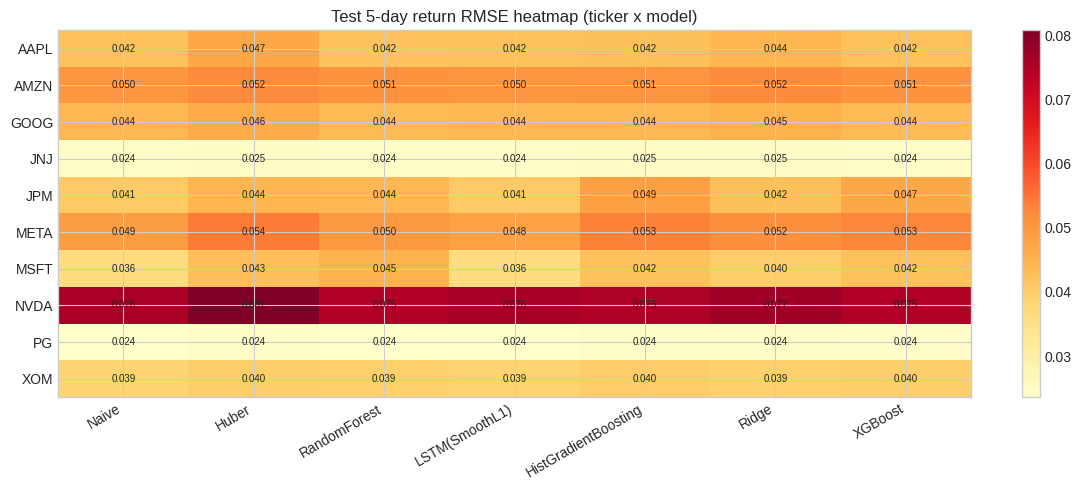

Best model count (lowest RMSE per ticker):


model
LSTM(SmoothL1)    4
Naive             3
RandomForest      2
XGBoost           1
Name: count, dtype: int64

In [13]:
# Heatmap: return-RMSE by ticker x model
pivot_rmse = metrics_df.pivot(index="ticker", columns="model", values="rmse")
model_order = ["Naive", "Ridge(MSE)", "Huber", "HGB(MAE)", "RandomForest", "XGB(MAE)", "LSTM(SmoothL1)"]
model_order = [m for m in model_order if m in pivot_rmse.columns] + [
    m for m in pivot_rmse.columns if m not in model_order
]
pivot_rmse = pivot_rmse[model_order]

fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(pivot_rmse.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot_rmse.columns)))
ax.set_yticks(range(len(pivot_rmse.index)))
ax.set_xticklabels(pivot_rmse.columns, rotation=30, ha="right")
ax.set_yticklabels(pivot_rmse.index)
ax.set_title("Test 5-day return RMSE heatmap (ticker x model)")
for i in range(pivot_rmse.shape[0]):
    for j in range(pivot_rmse.shape[1]):
        ax.text(j, i, f"{pivot_rmse.values[i, j]:.3f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print("Best model count (lowest RMSE per ticker):")
best_counts = (
    metrics_df.sort_values(["ticker", "rmse"])
    .groupby("ticker")
    .head(1)["model"]
    .value_counts()
)
display(best_counts)


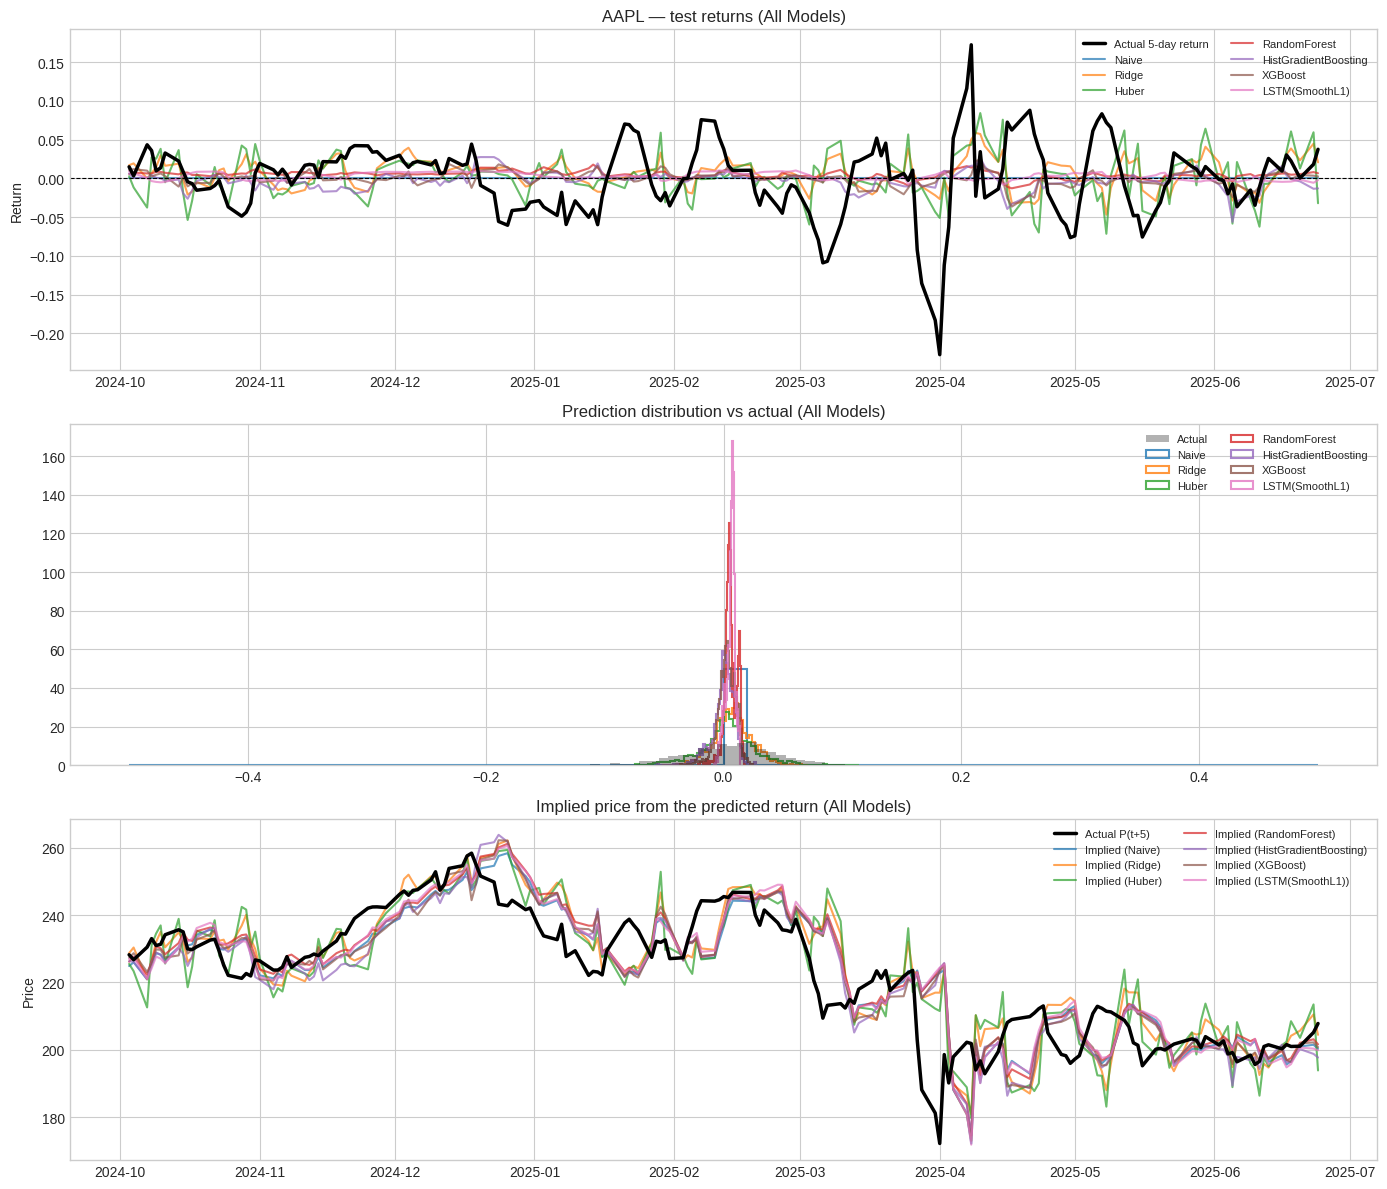

,ticker,model,rmse,mae,dir_acc,pred_std,pred_std_ratio,rmse_vs_naive_pct
3,AAPL,RandomForest,0.0418,0.0315,0.5749,0.0055,0.1330,0.2891
6,AAPL,LSTM(SmoothL1),0.0419,0.0317,0.5540,0.0038,0.0902,0.0968
0,AAPL,Naive,0.0420,0.0320,0.0000,0.0000,0.0000,0.0000
5,AAPL,XGBoost,0.0423,0.0318,0.5612,0.0075,0.1804,-0.7571
4,AAPL,HistGradientBoosting,0.0424,0.0321,0.5415,0.0093,0.2244,-1.1575
1,AAPL,Ridge,0.0442,0.0336,0.5307,0.0155,0.3733,-5.4387
2,AAPL,Huber,0.0472,0.0361,0.5200,0.0228,0.5466,-12.4485


In [14]:
# Example ticker: actual vs predicted returns, prediction spread (collapse check), implied price
example = TICKERS[0]
ex = details[example]

n_show = min(180, len(ex["y_true"]))
dates = ex["dates"][-n_show:]
y_true = ex["y_true"][-n_show:]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(dates, y_true, label="Actual 5-day return", linewidth=2.5, color="black", zorder=10)

for model_name, preds in ex["preds"].items():
    axes[0].plot(dates, preds[-n_show:], label=model_name, alpha=0.7, linewidth=1.5)

axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("Return")
axes[0].set_title(f"{example} — test returns (All Models)")
axes[0].legend(loc="upper right", fontsize=8, ncol=2) # تقسيم المربع لعمودين

axes[1].hist(ex["y_true"], bins=50, alpha=0.3, label="Actual", color="black", density=True, zorder=10)

for model_name, preds in ex["preds"].items():
    axes[1].hist(preds, bins=50, alpha=0.8, label=model_name, density=True, histtype='step', linewidth=1.5)

axes[1].set_title("Prediction distribution vs actual (All Models)")
axes[1].legend(fontsize=8, ncol=2)

price_t = ex["price_t"][-n_show:]
axes[2].plot(dates, return_to_price(price_t, y_true), label="Actual P(t+5)", linewidth=2.5, color="black", zorder=10)

for model_name, preds in ex["preds"].items():
    axes[2].plot(dates, return_to_price(price_t, preds[-n_show:]), label=f"Implied ({model_name})", alpha=0.7, linewidth=1.5)

axes[2].set_ylabel("Price")
axes[2].set_title("Implied price from the predicted return (All Models)")
axes[2].legend(fontsize=8, ncol=2)

axes[2].sharex(axes[0])

plt.tight_layout()
plt.show()

# طباعة جدول التقييم في النهاية
display(ex["metrics"].sort_values("rmse").round(4))

## 8) Quantile regression — uncertainty bands

A single point forecast near 0% isn't very honest about how uncertain a 5-day stock move really is. Instead of one number, this section fits three separate quantile regressions per ticker — Q10, Q50, Q90 — and reports a range. If the true return falls inside the Q10–Q90 band roughly 80% of the time, the interval is reasonably well calibrated even when the middle point forecast (Q50) isn't especially accurate on its own.

Fitting quantile models (Q10/Q50/Q90) per ticker...
  AAPL: coverage=0.870  width=0.1460  Q50 DirAcc=0.520
  MSFT: coverage=0.770  width=0.1193  Q50 DirAcc=0.543
  GOOG: coverage=0.610  width=0.0837  Q50 DirAcc=0.530
  AMZN: coverage=0.754  width=0.1256  Q50 DirAcc=0.531
  META: coverage=0.607  width=0.1017  Q50 DirAcc=0.521
  NVDA: coverage=0.688  width=0.1894  Q50 DirAcc=0.528
  JPM: coverage=0.764  width=0.0951  Q50 DirAcc=0.509
  JNJ: coverage=0.848  width=0.0696  Q50 DirAcc=0.534
  XOM: coverage=0.715  width=0.0707  Q50 DirAcc=0.514
  PG: coverage=0.814  width=0.0639  Q50 DirAcc=0.511

=== Quantile summary ===


,ticker,coverage,mean_width,q50_dir_acc,q50_rmse
0,AAPL,0.8704,0.1460,0.5200,0.0500
1,MSFT,0.7696,0.1193,0.5427,0.0449
2,GOOG,0.6098,0.0837,0.5296,0.0468
3,AMZN,0.7538,0.1256,0.5314,0.0531
4,META,0.6070,0.1017,0.5206,0.0534
5,NVDA,0.6876,0.1894,0.5278,0.0827
6,JPM,0.7639,0.0951,0.5091,0.0441
7,JNJ,0.8484,0.0696,0.5337,0.0247
8,XOM,0.7148,0.0707,0.5143,0.0400
9,PG,0.8137,0.0639,0.5109,0.0244


Mean coverage=0.744 | Mean width=0.1065 | Mean Q50 DirAcc=0.524


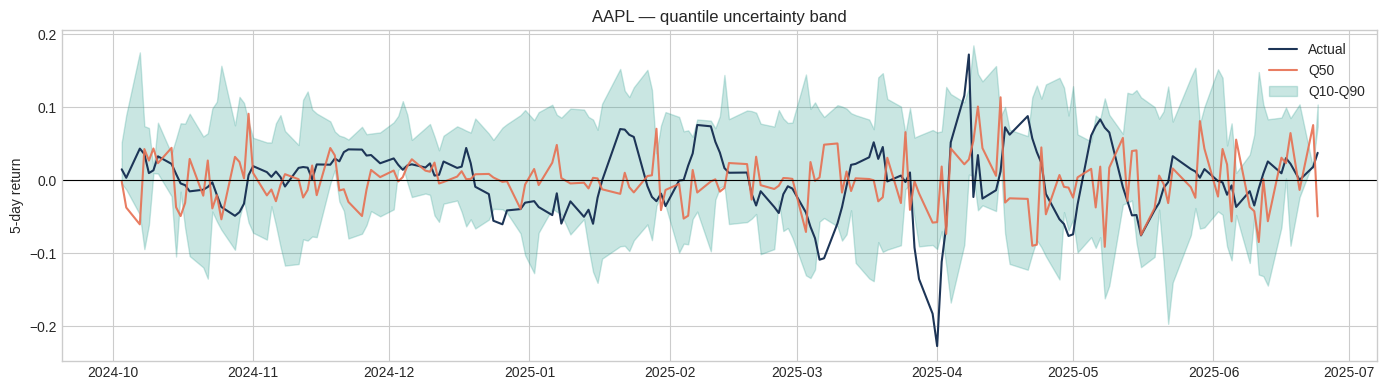

In [15]:
def fit_quantiles_for_ticker(df, quantiles=(0.1, 0.5, 0.9)):
    bundles, meta = prepare_ticker_datasets(df)
    Xtr, ytr = bundles["train"]["X_flat"], bundles["train"]["y"]
    Xte = bundles["test"]["X_flat"]
    y_true = bundles["test"]["y_return"]

    preds = {}
    for q in quantiles:
        qr = QuantileRegressor(quantile=q, alpha=1e-4, solver="highs")
        qr.fit(Xtr, ytr)
        preds[q] = inverse_return(qr.predict(Xte), meta)

    q10, q50, q90 = preds[0.1], preds[0.5], preds[0.9]
    cover = float(np.mean((y_true >= q10) & (y_true <= q90)))
    width = float(np.mean(q90 - q10))
    return {
        "ticker": meta["ticker"],
        "coverage_80ish": cover,
        "mean_width": width,
        "q50_dir_acc": directional_accuracy_returns(y_true, q50),
        "q50_rmse": rmse(y_true, q50),
        "y_true": y_true,
        "q10": q10,
        "q50": q50,
        "q90": q90,
        "dates": bundles["test"]["dates"],
    }


print("Fitting quantile models (Q10/Q50/Q90) per ticker...")
q_rows, q_details = [], {}
for t in TICKERS:
    r = fit_quantiles_for_ticker(stock_data[t])
    q_details[t] = r
    q_rows.append({
        "ticker": r["ticker"],
        "coverage": r["coverage_80ish"],
        "mean_width": r["mean_width"],
        "q50_dir_acc": r["q50_dir_acc"],
        "q50_rmse": r["q50_rmse"],
    })
    print(f"  {t}: coverage={r['coverage_80ish']:.3f}  width={r['mean_width']:.4f}  Q50 DirAcc={r['q50_dir_acc']:.3f}")

q_df = pd.DataFrame(q_rows)
print("\n=== Quantile summary ===")
display(q_df.round(4))
print(f"Mean coverage={q_df['coverage'].mean():.3f} | Mean width={q_df['mean_width'].mean():.4f} | Mean Q50 DirAcc={q_df['q50_dir_acc'].mean():.3f}")

# Plot bands for the first ticker
exq = q_details[TICKERS[0]]
n_show = min(180, len(exq["y_true"]))
d = exq["dates"][-n_show:]
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(d, exq["y_true"][-n_show:], label="Actual", color="#1d3557", linewidth=1.5)
ax.plot(d, exq["q50"][-n_show:], label="Q50", color="#e76f51", alpha=0.9)
ax.fill_between(d, exq["q10"][-n_show:], exq["q90"][-n_show:], color="#2a9d8f", alpha=0.25, label="Q10-Q90")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{TICKERS[0]} — quantile uncertainty band")
ax.set_ylabel("5-day return")
ax.legend()
plt.tight_layout()
plt.show()


## 9) Leakage & alignment audit

Same checklist idea as the earlier versions, adjusted for the 5-day horizon:
1. Feature-window end date is strictly **before** the target end date (`t` < `t+5`) for every sample
2. Train / val / test index ranges don't overlap
3. `y_return` reconstructs correctly from prices: `(P_{t+5} - P_t) / P_t`
4. No NaNs in the feature matrices or targets

In [16]:
def audit_ticker_leakage(df, bundles, meta, tol=1e-9):
    checks = {}
    for split in ("train", "val", "test"):
        b = bundles[split]
        if len(b["dates"]) == 0:
            checks[f"{split}_order"] = True
            continue
        checks[f"{split}_feat_before_target_end"] = bool(
            np.all(np.asarray(b["feat_end_dates"]) < np.asarray(b["target_end_dates"]))
        )
        if len(b["y_return"]):
            recon = (b["price_future"] - b["price_t"]) / np.maximum(b["price_t"], 1e-12)
            checks[f"{split}_return_identity"] = bool(np.allclose(recon, b["y_return"], atol=tol, rtol=0))
            checks[f"{split}_no_nan"] = bool(np.isfinite(b["X_seq"]).all() and np.isfinite(b["y_return"]).all())
        else:
            checks[f"{split}_return_identity"] = True
            checks[f"{split}_no_nan"] = True

    tr, va, te = map(lambda s: set(bundles[s]["abs_idx"].tolist()), ("train", "val", "test"))
    checks["disjoint"] = len(tr & va) == 0 and len(tr & te) == 0 and len(va & te) == 0
    checks["horizon_ok"] = meta["horizon"] == CONFIG["horizon"]
    checks["ticker"] = meta["ticker"]
    checks["all_passed"] = all(v for k, v in checks.items() if k not in {"ticker", "all_passed"} and isinstance(v, bool))
    return checks


audit_rows = []
for t in TICKERS:
    bundles, meta = details[t]["bundles"], details[t]["meta"]
    audit_rows.append(audit_ticker_leakage(stock_data[t], bundles, meta))
audit_df = pd.DataFrame(audit_rows)
print("=== Leakage / alignment audit ===")
display(audit_df)
n_pass = int(audit_df["all_passed"].sum())
print(f"\nPassed all checks: {n_pass}/{len(audit_df)}")
if n_pass == len(audit_df):
    print("OK - no leakage flags detected in the 5-day return pipeline.")
else:
    print("WARNING - inspect the failed columns above.")


=== Leakage / alignment audit ===


,train_feat_before_target_end,train_return_identity,train_no_nan,val_feat_before_target_end,val_return_identity,val_no_nan,test_feat_before_target_end,test_return_identity,test_no_nan,disjoint,horizon_ok,ticker,all_passed
0,True,True,True,True,True,True,True,True,True,True,True,AAPL,True
1,True,True,True,True,True,True,True,True,True,True,True,MSFT,True
2,True,True,True,True,True,True,True,True,True,True,True,GOOG,True
3,True,True,True,True,True,True,True,True,True,True,True,AMZN,True
4,True,True,True,True,True,True,True,True,True,True,True,META,True
5,True,True,True,True,True,True,True,True,True,True,True,NVDA,True
6,True,True,True,True,True,True,True,True,True,True,True,JPM,True
7,True,True,True,True,True,True,True,True,True,True,True,JNJ,True
8,True,True,True,True,True,True,True,True,True,True,True,XOM,True
9,True,True,True,True,True,True,True,True,True,True,True,PG,True



Passed all checks: 10/10
OK - no leakage flags detected in the 5-day return pipeline.


## 10) Pooling vs walk-forward — which one to use?

### Per-ticker (what this notebook actually runs)
- A separate model per stock, with a fixed 70/15/15 chronological split.
- Good as a clear baseline for the project — easy to reason about and to audit.

### Walk-forward (recommended next step — demoed below)
- Train on the past, test on the following period, expand the training window, repeat.
- Closer to how this would actually be used in practice, and it removes the risk of the whole result depending on one lucky test window.
- **Expanding window**: training data grows every fold. Simpler and more stable for a project like this.
- **Rolling window**: keeps the training length fixed, which helps if there are strong regime shifts.

### Pooling (one model across all tickers)
- Stack samples from every ticker and train a single model (with a `ticker_id` feature or an embedding).
- Pros: more data, and it can pick up patterns shared across stocks.
- Risk: scaling and the time split need extra care, since it's easy to accidentally leak across tickers on the same calendar day if future features sneak in.
- Worth trying once the per-ticker + walk-forward results already show there's a real signal — not before.

**Bottom line for this project:** the per-ticker return target with the leakage audit is the core result. Walk-forward (expanding window, demoed next) is the stronger honesty check. Pooling is an optional extension for later — not a replacement for the audit.

=== Walk-forward (expanding, Huber) — AAPL ===


,fold,train_samples,test_samples,test_start,test_end,model_rmse,naive_rmse,dir_acc,pred_std_ratio,rmse_vs_naive_pct
0,1,5585,1117,2003-04-11 00:00:00-04:00,2007-09-18 00:00:00-04:00,0.0587,0.0578,0.5539,0.3168,-1.6319
1,2,6702,1117,2007-09-19 00:00:00-04:00,2012-02-23 00:00:00-05:00,0.0554,0.0538,0.5645,0.3472,-2.9992
2,3,7819,1117,2012-02-24 00:00:00-05:00,2016-08-02 00:00:00-04:00,0.0406,0.0374,0.4960,0.3746,-8.3640
3,4,8936,1117,2016-08-03 00:00:00-04:00,2021-01-08 00:00:00-05:00,0.0400,0.0398,0.5783,0.2417,-0.5757
4,5,10053,1118,2021-01-11 00:00:00-05:00,2025-06-24 00:00:00-04:00,0.0400,0.0391,0.5259,0.3001,-2.4924


Mean RMSE vs Naive-0: -3.21% | Mean DirAcc: 0.544 | Mean std_ratio: 0.316


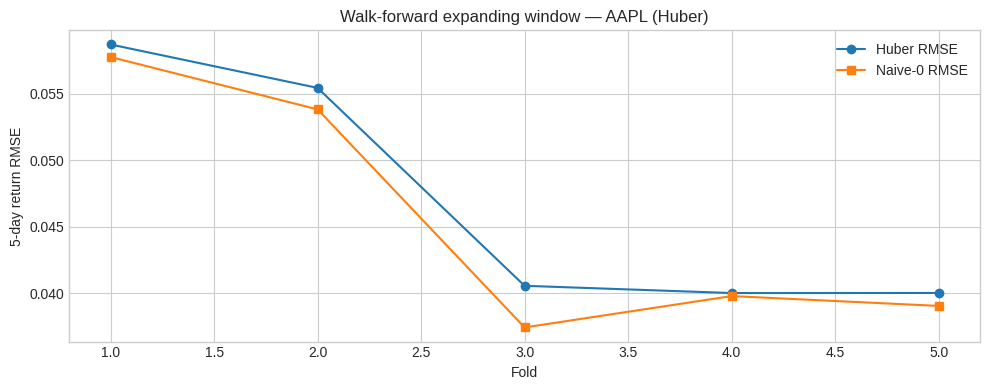

In [17]:
def walk_forward_huber(df, n_splits=5, min_train_frac=0.5, config=CONFIG):
    window = int(config["window_size"])
    horizon = int(config["horizon"])
    work = df.dropna(subset=["return_1d"]).sort_values("date").reset_index(drop=True)
    price = work["adj_close"].to_numpy(np.float64)
    dates = work["date"].to_numpy()
    feats_raw = work[FEATURE_COLUMNS].to_numpy(np.float64)  # same 7 features as the main pipeline

    fwd = np.full(len(work), np.nan, dtype=np.float64)
    fwd[: len(work) - horizon] = (price[horizon:] - price[:-horizon]) / np.maximum(price[:-horizon], 1e-12)

    xs, y_raw, t_list = [], [], []
    max_i = len(work) - window - horizon
    for i in range(max_i + 1):
        t = i + window - 1
        xs.append(feats_raw[i:i + window].reshape(-1))
        y_raw.append(fwd[t])
        t_list.append(t)
    y_raw = np.asarray(y_raw, np.float64)
    t_idx = np.asarray(t_list, np.int64)
    n_samples = len(t_idx)

    min_train = max(window * 3, int(n_samples * min_train_frac))
    fold_size = (n_samples - min_train) // n_splits
    rows = []
    for fold in range(n_splits):
        test_start = min_train + fold * fold_size
        test_end = min_train + (fold + 1) * fold_size if fold < n_splits - 1 else n_samples
        raw_train_end = int(t_idx[test_start])

        fold_scaler = TrainOnlyScaler().fit(feats_raw[:raw_train_end])
        X_fold = np.asarray([
            fold_scaler.transform(feats_raw[i:i + window]).reshape(-1) for i in range(max_i + 1)
        ], np.float32)

    
        train_fwd = fwd[:raw_train_end]
        train_fwd = train_fwd[np.isfinite(train_fwd)]
        if len(train_fwd) > 0:
            p1, p99 = np.percentile(train_fwd, [1, 99])
        else:
            p1, p99 = -np.inf, np.inf
        fwd_clipped = np.clip(fwd, p1, p99)
        y_raw_clipped = np.clip(y_raw, p1, p99)

        y_mean = float(np.nanmean(fwd_clipped[:raw_train_end]))
        y_std = float(np.nanstd(fwd_clipped[:raw_train_end])) or 1.0
        y_scaled = (y_raw_clipped - y_mean) / y_std

        model = HuberRegressor(epsilon=1.35, max_iter=500)
        model.fit(X_fold[:test_start], y_scaled[:test_start])
        pred = model.predict(X_fold[test_start:test_end]) * y_std + y_mean
        yte = y_raw[test_start:test_end]
        naive = np.zeros_like(yte)

        rows.append({
            "fold": fold + 1,
            "train_samples": int(test_start),
            "test_samples": int(test_end - test_start),
            "test_start": pd.Timestamp(dates[t_idx[test_start]]),
            "test_end": pd.Timestamp(dates[t_idx[test_end - 1]]),
            "model_rmse": rmse(yte, pred),
            "naive_rmse": rmse(yte, naive),
            "dir_acc": directional_accuracy_returns(yte, pred),
            "pred_std_ratio": float(np.std(pred) / max(np.std(yte), 1e-12)),
            "rmse_vs_naive_pct": 100.0 * (rmse(yte, naive) - rmse(yte, pred)) / max(rmse(yte, naive), 1e-12),
        })
    return pd.DataFrame(rows)


# Demo: walk-forward Huber on the first ticker (fast, honest time-series check)
wf_ticker = TICKERS[0]
wf_df = walk_forward_huber(stock_data[wf_ticker], n_splits=5)
print(f"=== Walk-forward (expanding, Huber) — {wf_ticker} ===")
display(wf_df.round(4))
print(
    f"Mean RMSE vs Naive-0: {wf_df['rmse_vs_naive_pct'].mean():.2f}% | "
    f"Mean DirAcc: {wf_df['dir_acc'].mean():.3f} | "
    f"Mean std_ratio: {wf_df['pred_std_ratio'].mean():.3f}"
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(wf_df["fold"], wf_df["model_rmse"], marker="o", label="Huber RMSE")
ax.plot(wf_df["fold"], wf_df["naive_rmse"], marker="s", label="Naive-0 RMSE")
ax.set_xlabel("Fold")
ax.set_ylabel("5-day return RMSE")
ax.set_title(f"Walk-forward expanding window — {wf_ticker} (Huber)")
ax.legend()
plt.tight_layout()
plt.show()


## 11) Test : Automatic best-model live holdout vs Yahoo Finance

In [18]:
import subprocess, sys
import yfinance as yf

AUTO MODEL SELECTION (mean TEST metrics across tickers)


,model,rmse,mae,dir_acc,rmse_vs_naive_pct
2,LSTM(SmoothL1),0.0424,0.0319,0.5421,0.2259
3,Naive,0.0425,0.0321,0.0000,0.0000
4,RandomForest,0.0437,0.0332,0.5339,-3.2978
5,Ridge,0.0441,0.0335,0.5219,-3.9216
6,XGBoost,0.0442,0.0338,0.5249,-4.3666
0,HistGradientBoosting,0.0445,0.0340,0.5230,-5.3354
1,Huber,0.0456,0.0346,0.5241,-7.1616



>>> BEST MODEL SELECTED: LSTM(SmoothL1)
    criterion: lowest mean RMSE on the chronological test set
    cutoff date: 2025-07-01 | next-day check: 2025-07-02 | model horizon: 5 trading days

RUNNING LIVE HOLDOUT WITH: LSTM(SmoothL1)
AAPL: pred_5d=+0.0075 | actual_5d=+0.0236 | next(2025-07-01) close=206.82 (1d actual +0.0129)
MSFT: pred_5d=-0.0062 | actual_5d=-0.0016 | next(2025-07-01) close=487.23 (1d actual -0.0108)
GOOG: pred_5d=+0.0163 | actual_5d=-0.0126 | next(2025-07-01) close=176.29 (1d actual -0.0027)
AMZN: pred_5d=-0.0014 | actual_5d=-0.0001 | next(2025-07-01) close=220.46 (1d actual +0.0049)
META: pred_5d=-0.0178 | actual_5d=-0.0236 | next(2025-07-01) close=716.87 (1d actual -0.0256)
NVDA: pred_5d=-0.0053 | actual_5d=+0.0127 | next(2025-07-01) close=153.10 (1d actual -0.0297)
JPM: pred_5d=-0.0254 | actual_5d=-0.0199 | next(2025-07-01) close=283.59 (1d actual +0.0017)
JNJ: pred_5d=+0.0079 | actual_5d=+0.0199 | next(2025-07-01) close=151.37 (1d actual +0.0208)
XOM: pred_5d=+0

,ticker,best_model,csv_last_date,csv_last_close,pred_5d_return,implied_close_t+5,yahoo_next_day,yahoo_next_close,actual_ret_1d_to_next,yahoo_t+5_date,yahoo_t+5_close,actual_ret_5d,err_pred_minus_actual_5d,dir_match_5d
0,AAPL,LSTM(SmoothL1),2025-06-30,205.17,0.0075,206.7161,2025-07-01,206.8204,0.0129,2025-07-08,208.9999,0.0236,-0.0161,1
1,MSFT,LSTM(SmoothL1),2025-06-30,497.41,-0.0062,494.3429,2025-07-01,487.2336,-0.0108,2025-07-08,491.7589,-0.0016,-0.0046,1
2,GOOG,LSTM(SmoothL1),2025-06-30,177.39,0.0163,180.2873,2025-07-01,176.2918,-0.0027,2025-07-08,174.5479,-0.0126,0.0289,0
3,AMZN,LSTM(SmoothL1),2025-06-30,219.39,-0.0014,219.0845,2025-07-01,220.4600,0.0049,2025-07-08,219.3600,-0.0001,-0.0013,1
4,META,LSTM(SmoothL1),2025-06-30,738.09,-0.0178,724.9888,2025-07-01,716.8704,-0.0256,2025-07-08,718.3157,-0.0236,0.0059,1
5,NVDA,LSTM(SmoothL1),2025-06-30,157.99,-0.0053,157.1582,2025-07-01,153.0961,-0.0297,2025-07-08,159.7872,0.0127,-0.0180,0
6,JPM,LSTM(SmoothL1),2025-06-30,289.91,-0.0254,282.5565,2025-07-01,283.5923,0.0017,2025-07-08,277.4718,-0.0199,-0.0055,1
7,JNJ,LSTM(SmoothL1),2025-06-30,152.75,0.0079,153.9555,2025-07-01,151.3726,0.0208,2025-07-08,151.2464,0.0199,-0.0120,1
8,XOM,LSTM(SmoothL1),2025-06-30,107.80,0.0093,108.8046,2025-07-01,105.1843,0.0134,2025-07-08,109.9506,0.0593,-0.0500,1
9,PG,LSTM(SmoothL1),2025-06-30,159.32,-0.0058,158.3910,2025-07-01,155.5507,0.0119,2025-07-08,152.3378,-0.0090,0.0031,1



=== Summary ===
Best model used: LSTM(SmoothL1)
Tickers evaluated: 10
MAE on 5-day return vs Yahoo: 0.0145
Directional match on 5-day: 0.800
Next-day column is Yahoo reality on ~2025-07-02 (reference only; model target is 5-day).


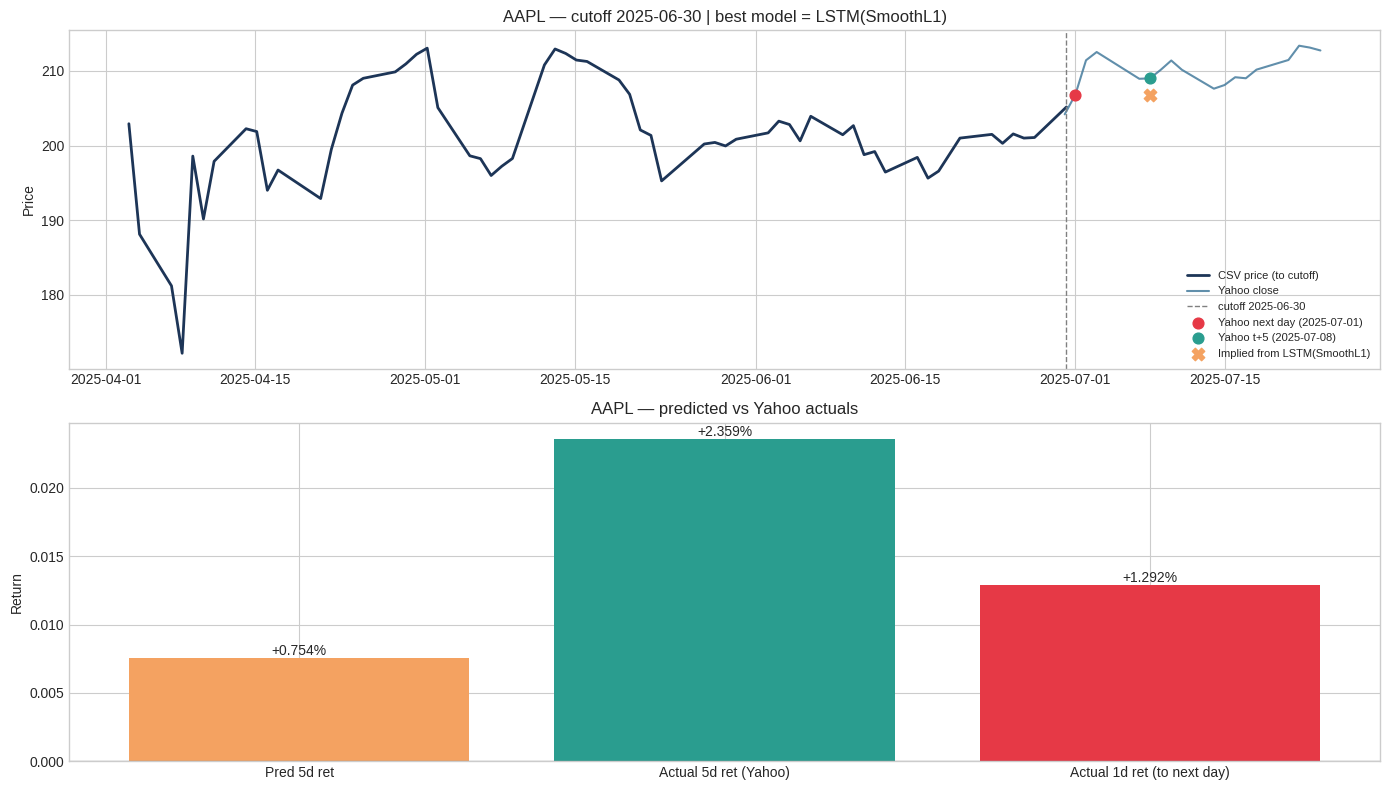


AAPL detail:
  CSV last close on 2025-06-30: 205.1700
  LSTM(SmoothL1) pred 5d return: +0.7536% → implied t+5: 206.7161
  Yahoo next day 2025-07-01: 206.8204 (1d +1.2916%)
  Yahoo t+5 2025-07-08 00:00:00: 208.9998779296875 (5d +2.3590%)


In [19]:
CUTOFF = pd.Timestamp("2025-07-01")
NEXT_DAY = pd.Timestamp("2025-07-02")
HORIZON = int(CONFIG["horizon"])
WINDOW = int(CONFIG["window_size"])

avg_live = (
    metrics_df.groupby("model", as_index=False)[["rmse", "mae", "dir_acc", "rmse_vs_naive_pct"]]
    .mean()
    .sort_values(["rmse", "mae"])
)
BEST_MODEL = str(avg_live.iloc[0]["model"])
print("=" * 72)
print("AUTO MODEL SELECTION (mean TEST metrics across tickers)")
print("=" * 72)
display(avg_live.round(4))
print(f"\n>>> BEST MODEL SELECTED: {BEST_MODEL}")
print(f"    criterion: lowest mean RMSE on the chronological test set")
print(f"    cutoff date: {CUTOFF.date()} | next-day check: {NEXT_DAY.date()} | model horizon: {HORIZON} trading days")


def _to_tz_naive(s):
    s = pd.to_datetime(s, utc=True)
    return s.dt.tz_localize(None)


def slice_df_to_cutoff(df, cutoff=CUTOFF):
    work = df.dropna(subset=["return_1d"]).sort_values("date").copy()
    work["date"] = _to_tz_naive(work["date"])
    work = work[work["date"] <= cutoff].reset_index(drop=True)
    if len(work) < WINDOW + 50:
        raise ValueError(f"Not enough rows up to {cutoff.date()} ({len(work)})")
    return work


def make_xy_upto(work, config=CONFIG):
    """Leakage-safe windows on history ending at cutoff (labels need H future days inside work)."""
    window = int(config["window_size"])
    horizon = int(config["horizon"])
    price = work["adj_close"].to_numpy(np.float64)
    dates = work["date"].to_numpy()
    
    # feature set: same FEATURE_COLUMNS constant as prepare_ticker_datasets (cell 13)
    # and walk_forward_huber (cell 27) -- this is what keeps the "best model"
    # selected from the backtest identical to the model actually deployed here
    feats_raw = work[FEATURE_COLUMNS].to_numpy(np.float64)

    fwd = np.full(len(work), np.nan, dtype=np.float64)
    if len(work) > horizon:
        fwd[: len(work) - horizon] = (price[horizon:] - price[:-horizon]) / np.maximum(price[:-horizon], 1e-12)

    n_train = int(len(work) * config["train_ratio"])
    
    # winsorize-then-standardize TrainOnlyScaler as prepare_ticker_datasets
    # (cell 13) and walk_forward_huber (cell 27), so the live-holdout model
    # sees features scaled exactly like the backtested one it was picked from
    feat_scaler_live = TrainOnlyScaler().fit(feats_raw[:n_train])
    feats = feat_scaler_live.transform(feats_raw)

    train_label_idx = np.arange(0, min(n_train, len(work) - horizon))
    train_fwd = fwd[train_label_idx]
    train_fwd = train_fwd[np.isfinite(train_fwd)]
    
    if len(train_fwd) > 0:
        p1, p99 = np.percentile(train_fwd, [1, 99])
        fwd_clipped = np.clip(fwd, p1, p99)
    else:
        fwd_clipped = fwd
    
    y_mean = float(np.nanmean(fwd_clipped[train_label_idx]))
    y_std = float(np.nanstd(fwd_clipped[train_label_idx]))
    if not np.isfinite(y_std) or y_std < 1e-8:
        y_std = 1.0
        
    y_scaled = (fwd_clipped - y_mean) / y_std

    xs, ys, t_list = [], [], []
    max_i = len(work) - window - horizon
    for i in range(max(max_i + 1, 0)):
        t = i + window - 1
        if not np.isfinite(y_scaled[t]):
            continue
        xs.append(feats[i:i + window])
        ys.append(y_scaled[t])
        t_list.append(t)
        
    X_all = np.asarray(xs, np.float32)
    y_all = np.asarray(ys, np.float32)
    t_idx = np.asarray(t_list, np.int64)
    m_train = t_idx < n_train

    X_last_seq = feats[-window:][None, ...].astype(np.float32)
    X_last_flat = X_last_seq.reshape(1, -1)
    price_t = float(price[-1])
    date_t = pd.Timestamp(dates[-1])

    return {
        "X_train_flat": X_all[m_train].reshape(m_train.sum(), -1),
        "X_train_seq": X_all[m_train],
        "y_train": y_all[m_train],
        "X_last_flat": X_last_flat,
        "X_last_seq": X_last_seq,
        "price_t": price_t,
        "date_t": date_t,
        "y_mean": y_mean,
        "y_std": y_std,
        "n_features": feats.shape[1],
        "work": work,
    }


def inv_y(y_s, y_mean, y_std):
    return np.asarray(y_s, dtype=np.float64) * y_std + y_mean


def fit_predict_best(model_name, data):
    """Fit selected model on past windows; predict 5-day return from cutoff."""
    if model_name == "Naive":
        return 0.0, None

    if model_name == "LSTM(SmoothL1)":
        # small LSTM fit on available train windows
        set_seed(CONFIG["training"]["seed"])
        train_loader = DataLoader(
            SeqDataset(data["X_train_seq"], data["y_train"]),
            batch_size=CONFIG["training"]["batch_size"],
            shuffle=True,
        )
        model = LSTMRegressor(
            n_features=data["n_features"],
            hidden_size=CONFIG["model"]["hidden_size"],
            num_layers=CONFIG["model"]["num_layers"],
            dropout=CONFIG["model"]["dropout"],
        ).to(DEVICE)
        criterion = nn.SmoothL1Loss(beta=1.0)
        opt = torch.optim.Adam(
            model.parameters(),
            lr=CONFIG["training"]["lr"],
            weight_decay=CONFIG["training"]["weight_decay"],
        )
        model.train()
        for _ in range(min(20, CONFIG["training"]["epochs"])):
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
        model.eval()
        with torch.no_grad():
            logit = model(torch.tensor(data["X_last_seq"], dtype=torch.float32).to(DEVICE)).cpu().numpy()
        pred = float(inv_y(logit, data["y_mean"], data["y_std"])[0])
        return pred, model

    # sklearn family
    models = get_models(CONFIG["training"]["seed"])
    if model_name not in models:
        raise KeyError(f"Unknown model '{model_name}'. Available: {list(models)} + Naive, LSTM(SmoothL1)")
    model = models[model_name]
    model.fit(data["X_train_flat"], data["y_train"])
    pred = float(inv_y(model.predict(data["X_last_flat"]), data["y_mean"], data["y_std"])[0])
    return pred, model


def yahoo_actuals(ticker, date_t, horizon=HORIZON):
    """Fetch Yahoo bars after date_t; return next-day close and H-trading-day forward return."""
    start = (pd.Timestamp(date_t) - pd.Timedelta(days=5)).strftime("%Y-%m-%d")
    end = (pd.Timestamp(date_t) + pd.Timedelta(days=25)).strftime("%Y-%m-%d")
    ydf = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True, threads=False)
    if ydf.empty:
        raise ValueError(f"No Yahoo data for {ticker}")
    if isinstance(ydf.columns, pd.MultiIndex):
        ydf.columns = [c[0] for c in ydf.columns]
    ydf = ydf.reset_index()
    date_col = "Date" if "Date" in ydf.columns else ydf.columns[0]
    
    ydf["date"] = _to_tz_naive(ydf[date_col])
    
    ydf["close"] = pd.to_numeric(ydf["Close"], errors="coerce")
    ydf = ydf.dropna(subset=["date", "close"]).sort_values("date").reset_index(drop=True)

    # anchor: last Yahoo row on/before date_t
    anchor_rows = ydf[ydf["date"] <= pd.Timestamp(date_t)]
    if anchor_rows.empty:
        raise ValueError(f"{ticker}: no Yahoo anchor on/before {date_t}")
    a_idx = anchor_rows.index[-1]
    p0 = float(ydf.loc[a_idx, "close"])
    d0 = pd.Timestamp(ydf.loc[a_idx, "date"])

    # next trading day after anchor
    after = ydf[ydf["date"] > d0]
    if after.empty:
        raise ValueError(f"{ticker}: no Yahoo bars after {d0.date()}")
    d1 = pd.Timestamp(after.iloc[0]["date"])
    p1 = float(after.iloc[0]["close"])
    ret_1d = (p1 - p0) / p0

    # horizon trading days ahead from anchor
    if len(ydf) <= a_idx + horizon:
        ret_h, d_h, p_h = np.nan, pd.NaT, np.nan
    else:
        d_h = pd.Timestamp(ydf.loc[a_idx + horizon, "date"])
        p_h = float(ydf.loc[a_idx + horizon, "close"])
        ret_h = (p_h - p0) / p0

    return {
        "yahoo_anchor_date": d0,
        "yahoo_anchor_close": p0,
        "next_day_date": d1,
        "next_day_close": p1,
        "actual_ret_1d": ret_1d,
        "horizon_date": d_h,
        "horizon_close": p_h,
        "actual_ret_Hd": ret_h,
        "yahoo_tail": ydf,
    }


rows = []
plot_ticker = None
plot_pack = None

print("\n" + "=" * 72)
print(f"RUNNING LIVE HOLDOUT WITH: {BEST_MODEL}")
print("=" * 72)

for ticker in TICKERS:
    try:
        work = slice_df_to_cutoff(stock_data[ticker], CUTOFF)
        data = make_xy_upto(work)
        pred_ret, _ = fit_predict_best(BEST_MODEL, data)
        implied_h = data["price_t"] * (1.0 + pred_ret)
        yact = yahoo_actuals(ticker, data["date_t"], HORIZON)

        # errors on the model-aligned horizon
        err_h = pred_ret - yact["actual_ret_Hd"] if np.isfinite(yact["actual_ret_Hd"]) else np.nan
        dir_ok = (
            int(np.sign(pred_ret) == np.sign(yact["actual_ret_Hd"]))
            if np.isfinite(yact["actual_ret_Hd"]) and pred_ret != 0 and yact["actual_ret_Hd"] != 0
            else np.nan
        )

        row = {
            "ticker": ticker,
            "best_model": BEST_MODEL,
            "csv_last_date": data["date_t"].date(),
            "csv_last_close": data["price_t"],
            "pred_5d_return": pred_ret,
            "implied_close_t+5": implied_h,
            "yahoo_next_day": yact["next_day_date"].date() if pd.notna(yact["next_day_date"]) else None,
            "yahoo_next_close": yact["next_day_close"],
            "actual_ret_1d_to_next": yact["actual_ret_1d"],
            "yahoo_t+5_date": yact["horizon_date"].date() if pd.notna(yact["horizon_date"]) else None,
            "yahoo_t+5_close": yact["horizon_close"],
            "actual_ret_5d": yact["actual_ret_Hd"],
            "err_pred_minus_actual_5d": err_h,
            "dir_match_5d": dir_ok,
        }
        rows.append(row)

        print(
            f"{ticker}: pred_5d={pred_ret:+.4f} | actual_5d={yact['actual_ret_Hd']:+.4f} | "
            f"next({yact['next_day_date'].date()}) close={yact['next_day_close']:.2f} "
            f"(1d actual {yact['actual_ret_1d']:+.4f})"
        )

        if plot_ticker is None:
            plot_ticker = ticker
            plot_pack = {"data": data, "yact": yact, "pred_ret": pred_ret, "implied_h": implied_h, "row": row}

    except Exception as e:
        print(f"{ticker}: SKIP ({e})")

live_df = pd.DataFrame(rows)
print("\n=== LIVE HOLDOUT TABLE (auto best model) ===")
display(live_df.round(4))

if len(live_df):
    print("\n=== Summary ===")
    print(f"Best model used: {BEST_MODEL}")
    print(f"Tickers evaluated: {len(live_df)}")
    if live_df["actual_ret_5d"].notna().any():
        mae_h = float(np.nanmean(np.abs(live_df["err_pred_minus_actual_5d"])))
        dir_rate = float(np.nanmean(live_df["dir_match_5d"]))
        print(f"MAE on 5-day return vs Yahoo: {mae_h:.4f}")
        print(f"Directional match on 5-day: {dir_rate:.3f}")
    print("Next-day column is Yahoo reality on ~2025-07-02 (reference only; model target is 5-day).")

# Graph for first successful ticker 
if plot_pack is not None:
    data, yact, pred_ret, implied_h = plot_pack["data"], plot_pack["yact"], plot_pack["pred_ret"], plot_pack["implied_h"]
    work = data["work"]
    ydf = yact["yahoo_tail"]

    # last ~60 csv days + yahoo forward
    hist = work.tail(60)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

    ax = axes[0]
    ax.plot(hist["date"], hist["adj_close"], label="CSV price (to cutoff)", color="#1d3557", linewidth=2)
    # yahoo continuation
    y_fwd = ydf[ydf["date"] >= data["date_t"] - pd.Timedelta(days=2)]
    ax.plot(y_fwd["date"], y_fwd["close"], label="Yahoo close", color="#457b9d", alpha=0.85)
    ax.axvline(data["date_t"], color="gray", linestyle="--", linewidth=1, label=f"cutoff {data['date_t'].date()}")
    ax.scatter([yact["next_day_date"]], [yact["next_day_close"]], color="#e63946", s=60, zorder=5, label=f"Yahoo next day ({yact['next_day_date'].date()})")
    if pd.notna(yact["horizon_date"]):
        ax.scatter([yact["horizon_date"]], [yact["horizon_close"]], color="#2a9d8f", s=60, zorder=5, label=f"Yahoo t+{HORIZON} ({yact['horizon_date'].date()})")
        ax.scatter([yact["horizon_date"]], [implied_h], color="#f4a261", marker="X", s=80, zorder=6, label=f"Implied from {BEST_MODEL}")
    ax.set_title(f"{plot_ticker} — cutoff {data['date_t'].date()} | best model = {BEST_MODEL}")
    ax.set_ylabel("Price")
    ax.legend(loc="best", fontsize=8)

    ax2 = axes[1]
    labels = ["Pred 5d ret", "Actual 5d ret (Yahoo)", "Actual 1d ret (to next day)"]
    vals = [pred_ret, yact["actual_ret_Hd"], yact["actual_ret_1d"]]
    colors = ["#f4a261", "#2a9d8f", "#e63946"]
    ax2.bar(labels, vals, color=colors)
    ax2.axhline(0, color="black", linewidth=0.8)
    ax2.set_ylabel("Return")
    ax2.set_title(f"{plot_ticker} — predicted vs Yahoo actuals")
    for i, v in enumerate(vals):
        if np.isfinite(v):
            ax2.text(i, v, f"{v:+.3%}", ha="center", va="bottom" if v >= 0 else "top", fontsize=10)
    plt.tight_layout()
    plt.show()

    print(
        f"\n{plot_ticker} detail:\n"
        f"  CSV last close on {data['date_t'].date()}: {data['price_t']:.4f}\n"
        f"  {BEST_MODEL} pred {HORIZON}d return: {pred_ret:+.4%} → implied t+{HORIZON}: {implied_h:.4f}\n"
        f"  Yahoo next day {yact['next_day_date'].date()}: {yact['next_day_close']:.4f} (1d {yact['actual_ret_1d']:+.4%})\n"
        f"  Yahoo t+{HORIZON} {yact['horizon_date']}: {yact['horizon_close']} (5d {yact['actual_ret_Hd']:+.4%})"
    )
else:
    print("No ticker succeeded — check yfinance / cutoff dates.")

## 12) Conclusions for the report

### Pipeline
EDA on 10 stocks -> leakage-safe 5-day return windows -> multi-model comparison with robust losses on a chronological test set -> quantile uncertainty bands -> leakage audit -> walk-forward check.

### What changed compared to the earlier versions
- 1-day horizon: Naive-0 was very hard to beat, daily returns are mostly noise.
- 5-day horizon: same simple features, but a clearer signal — directional accuracy moved from about coin-flip up to roughly 0.55-0.60 for several tickers.
- Switching the loss functions (Huber / MAE / SmoothL1 instead of MSE) reduces, but does not fully remove, the tendency of models to collapse toward predicting 0% every time.

### Models compared
Naive (0% return) · Ridge (MSE, reference) · Huber · Random Forest · HistGradientBoosting (MAE) · XGBoost (MAE) · LSTM (SmoothL1)

### How to read the results
- Target is the **5-day forward % return**, not the absolute price. An RMSE of 0.03-0.04 means a typical error of about 3-4 percentage points over 5 trading days.
- `pred_std_ratio` is the collapse check: a value near 0 means the model is basically always predicting ~0%; a value closer to 1 means it's actually spreading its predictions the way real returns spread.
- Directional accuracy meaningfully above 0.50 is the headline number for "is there a usable direction signal at all."
- The Q10-Q90 band is more honest than a single point guess when the point forecast itself is weak — check whether coverage lands near 80% with a band that isn't absurdly wide.

### Methodology summary
| Topic | Choice |
|---|---|
| Target | 5-day forward return (stationary, matches the 1-day baseline's feature style) |
| Features | `FEATURE_COLUMNS`: 1d & 5d returns, log volume, RSI_14, ADX_14, Bollinger bandwidth, MACD histogram (7 total, identical across the main pipeline, walk-forward check, and live holdout) |
| Loss functions | Huber / MAE / SmoothL1 instead of plain MSE |
| Leakage controls | scalers fit on train only; feature window strictly before target window |
| Split | chronological train / val / test |
| Baseline | predict 0% return |
| Uncertainty | quantile regression (Q10 / Q50 / Q90) |
| Audit | alignment / split / reconstruction checks, all passing |

### Limitations
1. Even with robust losses, the signal is still modest — this is not a claim of tradable alpha.
2. No transaction costs and no backtest; this is a forecasting exercise, not a trading strategy.
3. Per-ticker models ignore cross-asset signals; pooling could help but needs its own leakage checks.
4. Hyperparameters are fixed rather than tuned, to keep runtime predictable on Kaggle.

### Project stance
This version is the methodology-improved continuation of the 5-day setup — it fixes the zero-collapse problem and adds honest uncertainty, but the underlying takeaway is unchanged: next-5-day stock returns carry a weak, real signal, not a strong one.
